<a href="https://colab.research.google.com/github/GGPwis/Aprendizaje-Automatico/blob/main/_Estadistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###PARCIAL DE ESTADISTICA Y EXPLORACION DE DATOS:
**NOMBRE Y APELLIDO:** Gustavo Gabriel Portal


# PRIMERA PARTE: PROBABILIDAD

a) Un cerrajero se dio cuenta de que 1 de cada 8 clientes realizan algún tipo de reclamo por sus trabajos realizados. Si durante cierto día recibe a 7 clientes, ¿Cuál es la probabilidad de que 3 clientes realicen algún reclamo?

In [ ]:
import scipy.stats as st

n = 7         # número de ensayos
p = 1/8       # probabilidad de éxito
q = 7/8       # probabilidad de fracaso
x = 3         # cantidad de reclamos deseados

# Calcular P(X = 3)
prob_3 = st.binom.pmf(x, n, p)

print("Probabilidad de que 3 clientes realicen algun reclamo:")
print(f"P(X = 3) = {prob_3:.4f}")


Probabilidad de que 3 clientes realicen algun reclamo:
P(X = 3) = 0.0401


b) Una empresa de aviación determinó que 1% de las personas
que reservan cierto vuelo no se presentan. Por ello, decide vender 300 espacios para un avión que tiene 299 asientos.
Calcule la probabilidad de que todas las personas que se presenten tengan asiento disponible, suponiendo que las llegadas de los pasajeros siguen una distribución de Poisson.

In [ ]:
import scipy.stats as st
#Probabilidad de que almenos un pasajero no se presente:
#P(x>=1) = 1 - P(x<1)
#        = 1 - P(x=0)
#Promedio de pasajeros que faltan cada 300 boletos:
lmbda = 300 * 0.01 # lmbda = 3

# Probabilidad de que nadie falte (X = 0)
prob_x0 = st.poisson.pmf(0, lmbda)

# Probabilidad de que al menos una persona falte (todos tienen asiento)
prob_all_seated = 1 - prob_x0

print("Probabilidad de que nadie falte:")
print(f"P(X = 0) = {prob_x0:.4f}")
print("---")
print("Probabilidad de que todos consigan lugar:")
print(f"P(1 - P(x=0)) = {prob_all_seated:.4f}")

Probabilidad de que nadie falte:
P(X = 0) = 0.0498
---
Probabilidad de que todos consigan lugar:
P(1 - P(x=0)) = 0.9502


c) Las cajas de una marca de cereal contienen en promedio 85 gramos, con una desviación estándar de 2,5 gramos. Si se sabe que el proceso de llenado sigue una distribución normal. ¿Cuál es la probabilidad de que una caja de cereal contenga más de 88,4 gramos? ¿Cuál es la probabilidad de que una caja de cereal
contenga entre 86,9 gramos y 87,5 gramos?

In [ ]:
import scipy.stats as st

media = 85
desv_e = 2.5

#Probabilidad de que la caja tenga mas de 88.4g: P(X > 88.4)
z1 = (88.4 - media) / desv_e
prob_mayor_88_4 = 1 - st.norm.cdf(z1)

#Probabilidad de que ka caja contenga entre 86.9g y 87.5g: P(86.9 < X < 87.5)
z2 = (86.9 - media) / desv_e
z3 = (87.5 - media) / desv_e
prob_entre = st.norm.cdf(z3) - st.norm.cdf(z2)

print("Probabilidad de que la caja tenga mas de 88.4g:")
print(f"P(X > 88.4) = {prob_mayor_88_4:.4f}")
print("---")
print("Probabilidad de que la caja contenga entre 86.9g y 87.5g:")
print(f"P(86.9 < X < 87.5) = {prob_entre:.4f}")


Probabilidad de que la caja tenga mas de 88.4g:
P(X > 88.4) = 0.0869
---
Probabilidad de que la caja contenga entre 86.9g y 87.5g:
P(86.9 < X < 87.5) = 0.0650


# SEGUNDA PARTE: CLUSTERING CON EL METODO K-MEANS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

**Imprtacion de los datos**

In [ ]:
# Carga del Archivo
from google.colab import files
uploaded = files.upload()

Saving caracteristicas de vinos.csv to caracteristicas de vinos (1).csv


In [ ]:
vinos = pd.read_csv('caracteristicas de vinos.csv')

**Vemos las caracteristicas del objeto vinos**

In [ ]:
vinos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Vino             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


**Le pedimos que despliegue las primeras filas**

In [ ]:
vinos.head(2)

,Vino,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,2,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050


**Quitamos la columna "vino" del analisis de caracteristicas**

In [ ]:
vinos_variables=vinos.drop(['Vino'], axis=1)
vinos_variables.head(2)

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050


**oBTENEMOS LOS ESTADISTICOS DESCRIPTIVOS DE VINOS**

In [ ]:
vinos_variables.describe()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### normalizar los valores de las caracteristicas

In [ ]:
vinos_norm=(vinos_variables-vinos_variables.min())/(vinos_variables.max()-vinos_variables.min())
vinos_norm

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,0.842105,0.191700,0.572193,0.257732,0.619565,0.627586,0.573840,0.283019,0.593060,0.372014,0.455285,0.970696,0.561341
1,0.571053,0.205534,0.417112,0.030928,0.326087,0.575862,0.510549,0.245283,0.274448,0.264505,0.463415,0.780220,0.550642
2,0.560526,0.320158,0.700535,0.412371,0.336957,0.627586,0.611814,0.320755,0.757098,0.375427,0.447154,0.695971,0.646933
3,0.878947,0.239130,0.609626,0.319588,0.467391,0.989655,0.664557,0.207547,0.558360,0.556314,0.308943,0.798535,0.857347
4,0.581579,0.365613,0.807487,0.536082,0.521739,0.627586,0.495781,0.490566,0.444795,0.259386,0.455285,0.608059,0.325963
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.705263,0.970356,0.582888,0.510309,0.271739,0.241379,0.056962,0.735849,0.205047,0.547782,0.130081,0.172161,0.329529
174,0.623684,0.626482,0.598930,0.639175,0.347826,0.282759,0.086498,0.566038,0.315457,0.513652,0.178862,0.106227,0.336662
175,0.589474,0.699605,0.481283,0.484536,0.543478,0.210345,0.073840,0.566038,0.296530,0.761092,0.089431,0.106227,0.397290
176,0.563158,0.365613,0.540107,0.484536,0.543478,0.231034,0.071730,0.754717,0.331230,0.684300,0.097561,0.128205,0.400856


In [ ]:
vinos_norm.describe()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,0.518584,0.315484,0.538244,0.458502,0.323278,0.453487,0.356386,0.437460,0.372523,0.322363,0.388170,0.491460,0.334446
std,0.213639,0.220780,0.146708,0.172142,0.155244,0.215811,0.210730,0.234818,0.180555,0.197806,0.185831,0.260070,0.224613
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.350658,0.170455,0.454545,0.340206,0.195652,0.262931,0.182489,0.264151,0.264984,0.165529,0.245935,0.244505,0.158702
50%,0.531579,0.222332,0.534759,0.458763,0.304348,0.474138,0.378692,0.396226,0.361199,0.290956,0.394309,0.553114,0.282097
75%,0.696711,0.462945,0.640374,0.561856,0.402174,0.627586,0.534810,0.580189,0.485804,0.419795,0.520325,0.695971,0.504280
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Busqueda de la cantidad de clusters
**Calculando que tan similares son los individuos dentro de los clusters**

In [ ]:
wcss = [] #suma de los cuadrados

for i in range (1,11):
  kmeans = KMeans(n_clusters = i, max_iter = 300)
  kmeans.fit(vinos_norm) #aplicamos KMeans a los datos normalizados
  wcss.append(kmeans.inertia_)

**Graficando los resultados de WCSS para formar el Codo de Jambú**

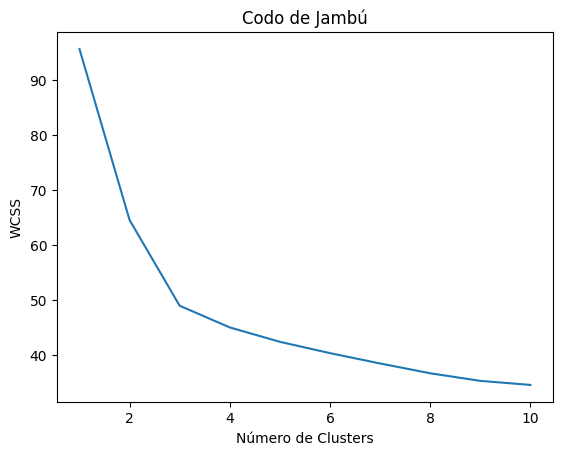

In [ ]:
plt.plot(range(1,11), wcss)
plt.title("Codo de Jambú")
plt.xlabel("Número de Clusters")
plt.ylabel("WCSS") #WCSS. Es un indicador de que tan similares son los individuis dentro de los clusters
plt.show()

#### Aplicamos el método k-means a la base de datos

In [ ]:
clustering = KMeans(n_clusters = 3, max_iter = 300) # Crea el modelo
clustering.fit(vinos_norm) #Aplica el modelo a la base de datos

KMeans(n_clusters=3)

### Agregando la clasificacion al archivo original

In [ ]:
vinos["KMeans_Clusters"] = clustering.labels_   #Los resultados del clusterin se guardan en labels_ dentro del modelo
vinos.head()

,Vino,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,KMeans_Clusters
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
1,2,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0
2,3,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0
3,4,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0
4,5,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0


### Visualizando los clusters que se formaron
**Aplicaremos el analisis de componentes principales para darnos una idea de como se formaron los clusters**

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_vinos = pca.fit_transform(vinos_norm)
pca_vinos_df=pd.DataFrame(data=pca_vinos, columns =["Componente_1", "Componente_2"])
pca_nombres_vinos = pd.concat([pca_vinos_df, vinos[["KMeans_Clusters"]]], axis=1)

pca_nombres_vinos

,Componente_1,Componente_2,KMeans_Clusters
0,0.706336,0.253193,0
1,0.484977,0.008823,0
2,0.521172,0.189187,0
3,0.821644,0.580906,0
4,0.202546,0.059467,0
...,...,...,...
173,-0.739510,0.471901,1
174,-0.581781,0.348366,1
175,-0.626313,0.546857,1
176,-0.572991,0.425516,1


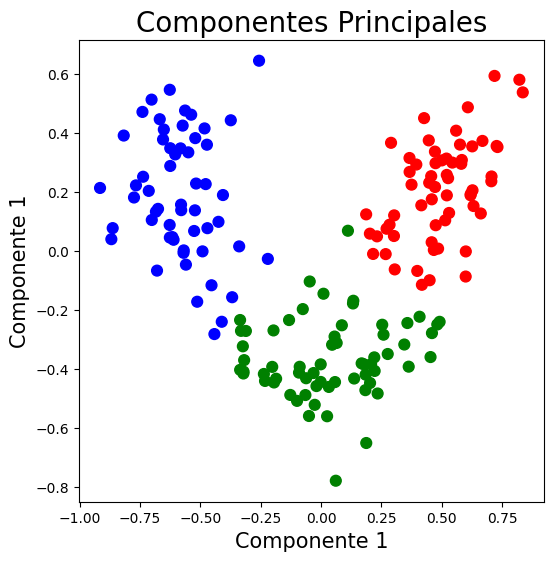

In [ ]:
fig = plt.figure(figsize = (6,6))

ax = fig.add_subplot(1,1,1)
ax.set_xlabel("Componente 1", fontsize = 15)
ax.set_ylabel("Componente 1", fontsize = 15)
ax.set_title("Componentes Principales", fontsize = 20)

color_theme = np.array(["blue", "green", "red"])
ax.scatter(x = pca_nombres_vinos.Componente_1, y = pca_nombres_vinos.Componente_2,
           c = color_theme[pca_nombres_vinos.KMeans_Clusters], s = 60)
plt.show()

Primero se aplicó K-Means para identificar grupos naturales de vinos según sus características químicas. Para determinar la cantidad óptima de clusters, se utilizó el método del codo, que analiza la variación de la suma de los cuadrados dentro de cada grupo. Esto reveló que tres clusters eran adecuados.

Luego, se usó PCA para reducir la dimensionalidad del conjunto de datos y facilitar la visualización de los grupos en dos dimensiones. Al proyectar los datos en estos componentes principales, se pudo ver cómo los clusters estaban distribuidos en el espacio.

Esta combinación de técnicas permitió interpretar mejor las similitudes entre vinos, sin depender de la clasificación original.

# TERCERA PARTE: ANALISIS DE GRAFICOS.

- **Matriz de Correlacion:**

¿Como se relacionan las distintas variables?

Rta: Con la matriz de correlacion notamos diferentes corelaciones positivas, negativas y las que no son excluyentes practicamente entre si. algunas de esas correlaciones altas son:
`Phenols` y `Flavanoids` tienen una correlación muy alta (0.86), lo que indica que aumentan o disminuyen juntas.
`Proline` y `Alcohol` también están bastante correlacionadas (0.64).
`KMeans_Clusters` tiene fuerte correlación negativa con `Proline` (-0.78), lo cual sugiere que esta variable fue clave para agrupar los vinos.

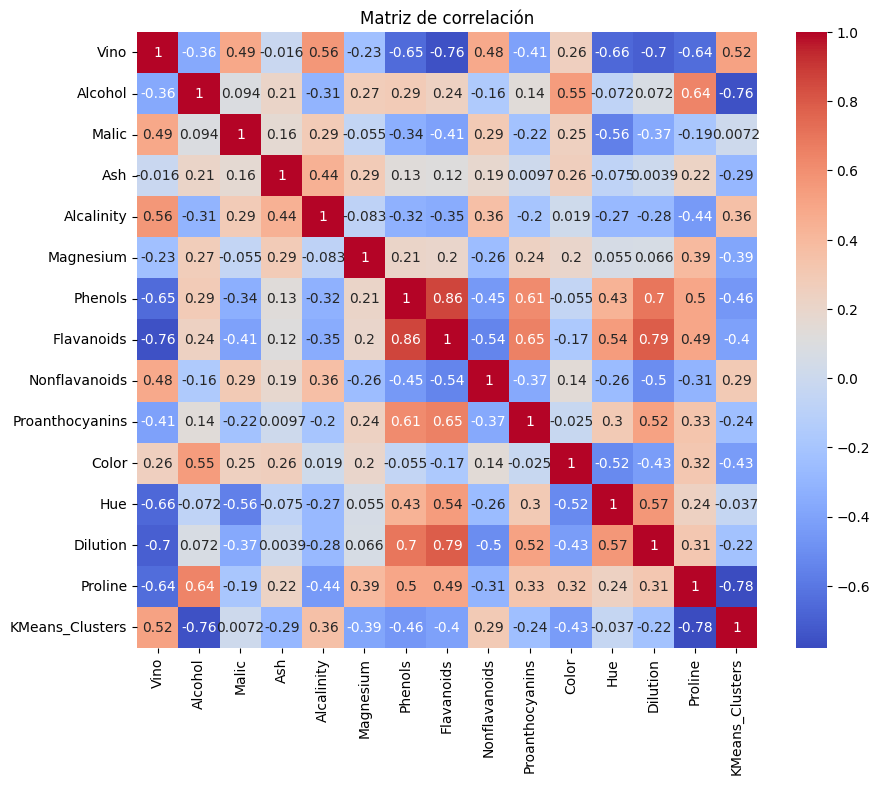

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(vinos.corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

- **Grafico de Barras:**

¿En cual grupo se encuentra la mayor concentracion de Alcohol?

Rta: Con el grafico de barras podemos ver que el Cluster_0 posee los vinos con mayor concentracion de alcohol, seguidos por el Cluster_2 y por ultimo el Cluster_1 con la menor concentracion de alcohol.


In [ ]:
import plotly.express as px
# Crear un gráfico de barras usando plotly express
fig = px.bar(vinos, x="KMeans_Clusters", y="Alcohol", title="Clusters con Mas Alcohol")
 # Actualice el diseño para incluir texto
fig.update_traces(hovertext=vinos['Vino'])
 # Mostrar la trama
fig.show()